In [1]:
from importlib.metadata import version
print("langchain version: ", version("langchain"))
print("langgraph version: ", version("langgraph"))
print("langchain-openai version: ", version("langchain-openai"))
print("langchain-core version: ", version("langchain-core"))
print("langchain_community version: ", version("langchain_community"))
print("langchain_mcp_adapters version: ", version("langchain_mcp_adapters"))
print("tavily-python version: ", version("tavily-python"))

langchain version:  1.2.10
langgraph version:  1.0.9
langchain-openai version:  1.1.11
langchain-core version:  1.2.19
langchain_community version:  0.4.1
langchain_mcp_adapters version:  0.2.1
tavily-python version:  0.7.21


In [2]:
import os
from dotenv import load_dotenv
import openai
load_dotenv()

True

2026-03-25 11:07:20 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'draft' with handle 'gpt-5.4-nano' (timeout=600)
2026-03-25 11:07:22 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_summarizer' with handle 'gpt-5.4-nano' (timeout=600)
2026-03-25 11:07:22 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'writer' with handle 'gpt-5.4-nano' (timeout=600)
2026-03-25 11:07:22 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_main' with handle 'gpt-5.4-nano' (timeout=600)
2026-03-25 11:07:22 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_compressor' with handle 'gpt-5.4-nano' (timeout=600)
2026-03-25 11:07:22 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'red_team' with handle 'gpt-5.4-mini' (timeout=600)
2026-03-25 11:07:22 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'evaluator' with handle

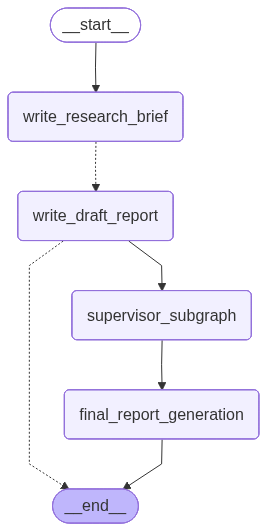

In [3]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research.agent_builder import deep_researcher_builder
import warnings

warnings.filterwarnings("ignore")
checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# take 10 ~ 20 minutes to finish the task.
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="我是个 AI 产品经理，正在考虑给产品增加个性化记忆功能。想系统了解一下现在 Agent 里的 Memory 模块都在往哪些方向发展，包括短期和长期记忆是怎么做的、各种技术路线的差异和取舍。你帮我写个调研报告，从工程落地和未来演进的角度分析一下 哪些方向更值得投入")]}, config=thread)

2026-03-25 11:08:09 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=0, messages=2)
2026-03-25 11:08:11 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-03-25 11:08:11 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=1 conduct=0 refine=0
2026-03-25 11:08:11 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=1, messages=4)
2026-03-25 11:08:13 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=3
2026-03-25 11:08:13 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=0 conduct=3 refine=0
2026-03-25 11:08:14 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=True num_tool_calls=1
2026-03-25 11:08:14 [INFO] deep_research.agents.research_agent: should_continue decision=tool_node (has_tool_calls=True)
2026-03-25 11:08:14 [INFO] 

In [7]:
from rich.console import Console
from rich.markdown import Markdown

# 创建控制台对象
console = Console()
console.print(Markdown(result["final_report"]))

Agent 个性化记忆（Memory）模块调研报告：短期/长期机制、写入-检索策略、工程落地与产品优先级（截至 2026-03-25）   

1. 执行结论：更值得优先投入的“可控记忆架构”                                                                        

综合现有一手资料（OpenAI Memory 产品语义、LangChain/LangGraph 的短期/长期工程组织、Chroma/Milvus 的向量存储 CRUD   
与检索接口、以及 Anthropic/Google 的上下文缓存能力），可以将“Agent 的 Memory”工程化拆解为：作用域分层（短期/长期）+
状态持久化（checkpointer/stores）+ 受控读取（可选择引用与检索注入）+ 用户治理开关（查看/删除/临时隔离）。          

在“低延迟/高可控/可迭代/可回滚”的产品目标下，更值得优先投入的路径是：                                              

 1 P0：短期记忆的稳定化与上下文治理                                                                                
   以 thread/scoped state 为核心，通过 checkpointer 保证线程可恢复；并用 Trim/Delete/Summarize                     
   等策略治理长对话上下文膨胀与过时信息干扰。[2][3]                                                                
 2 P1：长期记忆的结构化持久化与用户治理（Saved-type 优先）                                                         
   以 profile/collection + namespace 的结构化条目模型实现跨会话记忆；在产品上提供类似 OpenAI Memory                
   的开关与可删除治理，并把“临时对话隔离（Temporary Chat）”作为降低误写风险的杠杆。[1][4]                          
 3 P2：写入与冲突的“工程闭环 v0”优先于追求端到端学习型记忆                                                         
   当前一手资料普遍缺少对“长期写入触发阈值、并发冲突融合算法、自动回滚细则”的公开工程实现；因此为了避免误记导致行为
   偏差，需要自研最小可执行闭环（版本化、冲突标记、降权/回滚触发、审计与评测指标）。该部分属于工程必要补齐，不应被 
   当作已有公开共识。[1][2][4][5]                                                                                  
 4 RAG/向量检索作为“长期记忆的受控读取手段”，而非记忆本体的唯一实现                                                
   Chroma/Milvus 一手资料证明其具备增删改查、metadata filter、retriever、MMR、hybrid/full-text、rerank             
   等能力，可将“检索新鲜度/置信度/冲突惩罚”融入重排链路。[6][7]                                                    

▌ 重要不确定性声明：现有一手资料在“长期记忆的冲突判定、自动融合、回滚一致性与并发写一致性”的细粒度规则上披露不足 
▌ ；相关算法必须通过工程实现与评测验证，而不能直接外推为行业共识。[1][2][4][6][7]                                

-------------------------------------------------------------------------------------------------------------------

2. 研究范围与记忆“边界划分”的共识/缺口                                                                             

2.1 共识：以作用域（scope）与载体（store）划分，而非仅以“时间长度”划分                                             

LangChain/LangGraph 的 Memory 概览明确区分短期记忆（thread-scoped）与长期记忆（跨线程共享的                        
namespace/store），强调“短期作为 agent state 的一部分持久化恢复；长期通过 stores 持久保存并可跨线程召回”。[2]      
OpenAI 的 Memory 产品语义也将“Saved memories（持久）”与“Chat history（引用）”区分，并提供“Temporary                
Chat（隔离）”保证不会引用或更新既有记忆。[1][4]                                                                    

据此，在产品建模上更可靠的边界划分是：                                                                             

 • 短期记忆 = 当前线程/会话的状态与上下文治理结果（由 checkpointer/state 管理）。[2][3]                            
 • 长期记忆 = 跨会话可持久化、可治理的数据条目集合（由 namespace/stores/vector/profile 管理）。[2][1]              

2.2 缺口：公开资料未给出可复核的“自动写入触发阈值、冲突回滚算法、质量评估与自动回滚共识”                           

现有公开资料明确提到 OpenAI 会在“用户要求记住/忘记”时自动管理 saved                                                
memories（更新、合并或移除），并强调用户可删除/关闭/重置；但未披露写入触发的阈值细则、冲突检测的判定规则、以及回滚 
一致性的工程算法。[4]                                                                                              

LangChain/LangGraph 的短期记忆章节提供了 Trim/Delete/Summarize 与 checkpointer                                     
的工程机制；但在已摘录内容中，同样未出现“版本化回滚/冲突融合/并发一致性”的直接规则。[2][3]                         
向量库（Chroma/Milvus）提供向量 CRUD                                                                               
与检索能力（这对写入/检索非常关键），但并未在接口层明确提供“记忆语义层”的冲突融合或回滚策略。[6][7]                

因此，第 8 章给出的“回滚/冲突最小可执行闭环（MVE）”属于工程补齐方案，而不是从公开资料提取的“既有共识”。[4][6][7]   

-------------------------------------------------------------------------------------------------------------------

3. 短期记忆（Short-term Memory）：窗口保留、写入/遗忘时机与检索协作                                                

3.1 实现机制：thread-scoped state + checkpointer（低延迟、高可控）                                                 

LangChain/LangGraph 将短期记忆视为 agent state 的组成部分，并通过 checkpointer                                     
将状态持久化到数据库，使线程可随时恢复。[2][3]                                       

In [7]:
from datetime import date
path = f"./output_report_{date.today().strftime("%Y-%m-%d")}.md"
with open(path, "w") as fd:
    fd.write(result["final_report"])
print(f"调研报告已保存在{path}.")

调研报告已保存在./output_report_2026-03-21.md.


In [8]:
print(result["final_report"])

# Agent 个性化记忆（Memory）模块调研报告：短期/长期机制、写入-检索策略、工程落地与产品优先级（截至 2026-03-25）

## 1. 执行结论：更值得优先投入的“可控记忆架构”

综合现有一手资料（OpenAI Memory 产品语义、LangChain/LangGraph 的短期/长期工程组织、Chroma/Milvus 的向量存储 CRUD 与检索接口、以及 Anthropic/Google 的上下文缓存能力），可以将“Agent 的 Memory”工程化拆解为：**作用域分层（短期/长期）+ 状态持久化（checkpointer/stores）+ 受控读取（可选择引用与检索注入）+ 用户治理开关（查看/删除/临时隔离）**。

在“低延迟/高可控/可迭代/可回滚”的产品目标下，更值得优先投入的路径是：

1) **P0：短期记忆的稳定化与上下文治理**  
以 thread/scoped state 为核心，通过 checkpointer 保证线程可恢复；并用 Trim/Delete/Summarize 等策略治理长对话上下文膨胀与过时信息干扰。[2][3]

2) **P1：长期记忆的结构化持久化与用户治理（Saved-type 优先）**  
以 profile/collection + namespace 的结构化条目模型实现跨会话记忆；在产品上提供类似 OpenAI Memory 的开关与可删除治理，并把“临时对话隔离（Temporary Chat）”作为降低误写风险的杠杆。[1][4]

3) **P2：写入与冲突的“工程闭环 v0”优先于追求端到端学习型记忆**  
当前一手资料普遍缺少对“长期写入触发阈值、并发冲突融合算法、自动回滚细则”的公开工程实现；因此为了避免误记导致行为偏差，需要自研最小可执行闭环（版本化、冲突标记、降权/回滚触发、审计与评测指标）。该部分属于工程必要补齐，**不应被当作已有公开共识**。[1][2][4][5]

4) **RAG/向量检索作为“长期记忆的受控读取手段”，而非记忆本体的唯一实现**  
Chroma/Milvus 一手资料证明其具备增删改查、metadata filter、retriever、MMR、hybrid/full-text、rerank 等能力，可将“检索新鲜度/置信度/冲突